In [1]:
from PattRecClasses import DiscreteD, GaussD, HMM, MarkovChain
from matplotlib import pyplot as plt

import numpy as np

In [2]:
def load_array(filename):
    x = []
    with open(filename, 'r') as f:
        for line in f.read().splitlines():
            values = line.split(';')
            x.append(np.array([float(v) for v in values[1:]]))
    return np.array(x).T

def moving_average(x, n=10):
    average = np.zeros_like(x)
    for i in range(x.shape[1]):
        start = max(0, i - n + 1)
        average[:, i] = np.mean(x[:, start:i+1], axis=1)
    return average    
    

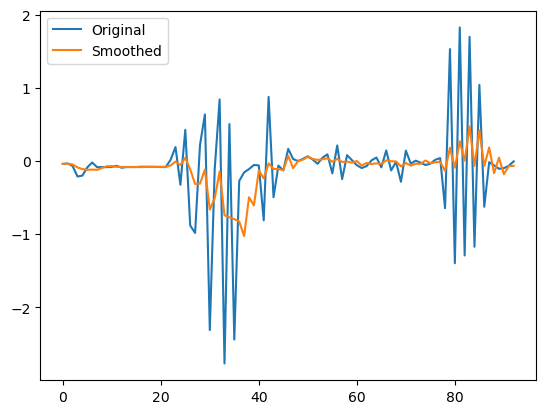

Log-likelihood: -308.10372463953576, Log-likelihood difference: inf
Log-likelihood: 90.10954500947656, Log-likelihood difference: 398.2132696490123
Log-likelihood: 103.79923739657012, Log-likelihood difference: 13.689692387093558
Log-likelihood: 116.44444412042786, Log-likelihood difference: 12.64520672385774
Log-likelihood: 116.44444412105256, Log-likelihood difference: 6.246949624255649e-10
q [4.63897334e-36 7.64450666e-01 2.35549334e-01]
A [[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
means_0 [-0.10486679 -0.2164253  -0.95437092]
means_1 [-0.03894043 -0.45123291 -0.8653717 ]
means_2 [-0.03894043 -0.45123291 -0.8653717 ]
cov_0 [[ 0.05472335  0.00818385 -0.00566058]
 [ 0.00818385  0.04895177 -0.01247509]
 [-0.00566058 -0.01247509  0.01561757]]
cov_1 [[1.e-10 0.e+00 0.e+00]
 [0.e+00 1.e-10 0.e+00]
 [0.e+00 0.e+00 1.e-10]]
cov_2 [[1.e-10 0.e+00 0.e+00]
 [0.e+00 1.e-10 0.e+00]
 [0.e+00 0.e+00 1.e-10]]
Log-likelihood -308.10372463953576


In [3]:
t = 4
pi = np.array( [ 0.3, 0.4, 0.4 ] )
A = np.array( [ [ 0.9998, 0.0001, 0.0001], [ 0.9998, 0.0001, 0.0001 ], [ 0.9998, 0.0001, 0.0001 ] ] )
mu_0 = np.array( [ 0.0, 0.0, 0.0 ] )
sigma_0 = np.array( [ [ 1.0, 0.0, 0.0 ], [ 0.0, 1.0, 0.0 ], [ 0.0, 0.0, 1.0 ] ] )
mu_1 = np.array( [ -3.0, -3.0, -3.0 ] )
sigma_1 = np.array( [ [ 4.0, 0.0, 0.0 ], [ 0.0, 4.0, 0.0 ], [ 0.0, 0.0, 4.0 ] ] )
mu_2 = np.array( [ 3.0, 3.0, 3.0 ] )
sigma_2 = np.array( [ [ 4.0, 0.0, 0.0 ], [ 0.0, 4.0, 0.0 ], [ 0.0, 0.0, 4.0 ] ] )
mc = MarkovChain( pi, A )
g1 = GaussD( means=mu_0, cov=sigma_0 )
g2 = GaussD( means=mu_1, cov=sigma_1 )
g3 = GaussD( means=mu_2, cov=sigma_2 )
h  = HMM( mc, [g1, g2, g3])
X = load_array("./data/text-E20790643EF3-1.txt")

X_smooth = moving_average(X, n=5)

plt.plot(X[0], label='Original')
plt.plot(X_smooth[0], label='Smoothed')
plt.legend()
plt.show()

prob, a_hat, b_hat, c, pX = h.logprob(X_smooth)
_ = h.train(X_smooth)
print('q',h.stateGen.q)
print('A',h.stateGen.A)
print('means_0',h.outputDistr[0].means)
print('means_1',h.outputDistr[1].means)
print('means_2',h.outputDistr[2].means)
print('cov_0',h.outputDistr[0].cov)
print('cov_1',h.outputDistr[1].cov)
print('cov_2',h.outputDistr[2].cov)
print('Log-likelihood',prob)

